In [37]:
import joblib
import re

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import Audio

import numpy as np
import pandas as pd

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths

paths = load_project_paths()

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")
taxonomy = pd.read_csv(paths.taxonomy)

In [39]:
taxonomy_map = taxonomy.set_index("primary_label")["common_name"] 
idx = le_primary_label.transform(taxonomy_map.index)
values = taxonomy_map.values
taxonomy_map = values[np.argsort(idx)]

filenames_subset = [
    "BC2026_Train_0008_S09_20250831_000000.ogg",
    "BC2026_Train_0064_S23_20241124_032002.ogg",
    "BC2026_Train_0014_S13_20220228_214500.ogg",
    "BC2026_Train_0007_S09_20250829_000000.ogg"
]

display(Audio(paths.soundscapes_clean_dir / "BC2026_Train_0008_S09_20250831_000000.ogg"))

In [40]:
class_colors = {
    "Aves": "#3B82F6",
    "Mammalia": "#F97316",
    "Amphibia": "#12843C",
    "Reptilia": "#EF4444",
    "Insecta": "#A855F7",
}

classes = list(class_colors.keys())
colors = [class_colors[c] for c in classes]

class_name_cmap = mcolors.ListedColormap(colors)

def balanced_group_sampling(y_class_name, n_per_group=1000, seed=42):
    rng = np.random.default_rng(seed)
    idx_all = []

    for g in np.unique(y_class_name):
        idx_g = np.where(y_class_name == g)[0]

        if len(idx_g) == 0:
            continue
        if len(idx_g) > n_per_group:
            chosen = rng.choice(idx_g, size=n_per_group, replace=False)
        else:
            chosen = idx_g  # keep all, no resampling

        idx_all.append(chosen)

    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)

    return idx_all

def fit_umap(dataset):

    y_class_name = le_class_name.inverse_transform(dataset.y[:, 0])
    y_primary_label = le_primary_label.inverse_transform(dataset.y[:, 1])

    idx = balanced_group_sampling(y_class_name=dataset.y[:, 0])

    X_sample = dataset.X[idx]
    y_sample = dataset.y[idx, 0]
    y_class_name_sample = y_class_name[idx]
    y_primary_label_sample = y_primary_label[idx]

    model = umap.UMAP(n_neighbors=30, random_state=42, metric="euclidean", n_components=2)
    embeddings = model.fit_transform(X_sample)
    
    return model, embeddings, y_class_name_sample, y_primary_label_sample

def plot_umap_by_class(embeddings, target_class):
    """
    Plot UMAP/PCA embeddings for one class,
    coloring primary labels with a local palette derived from base class color.
    """

    mask = (y_class_name_sample == target_class)

    emb = embeddings[mask]
    labels = np.array(y_primary_label_sample)[mask]

    unique_labels = np.unique(labels)
    n = len(unique_labels)

    base_hex = class_colors[target_class]
    base_rgb = np.array(mcolors.to_rgb(base_hex))

    # create local palette by interpolating brightness
    # (keeps semantic class color identity but separates species)
    factors = np.linspace(0.4, 1.2, n)

    colors = []
    for f in factors:
        col = np.clip(base_rgb * f, 0, 1)
        colors.append(col)

    lut = dict(zip(unique_labels, colors))
    point_colors = np.array([lut[l] for l in labels])

    # plot
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=point_colors,
        s=8,
        alpha=0.8,
        edgecolors="none",
        label="soundscapes"
    )

    ax.set_title(f"{target_class} ({n} primary labels)")
    ax.set_xlim(embeddings[:, 0].min()-0.5, embeddings[:, 0].max()+0.5)
    ax.set_ylim(embeddings[:, 1].min()-0.5, embeddings[:, 1].max()+0.5)

    return fig

### 5 seconds chunks

In [41]:
run_name = "run_chunks_overlap"
dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=False)
dataset_ss = load_memmap_dataset(run_name, reduced=True, soundscape=True)
model, embeddings, y_class_name_sample, y_primary_label_sample = fit_umap(dataset)

filenames = np.array(dataset_ss.filenames)
unique_filenames = np.unique(filenames)

embeddings_ss = model.transform(dataset_ss.X)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [42]:
def plot_ss_trajectory(target_file):
    # pick one soundscape file (first one in dataset)

    mask = filenames == target_file
    emb = embeddings_ss[mask]

    fig, ax = plt.subplots(figsize=(10, 5))
    species = le_primary_label.inverse_transform(np.where(dataset_ss.y[mask, 1, :].any(axis=0))[0])
    mask = np.where(np.isin(y_primary_label_sample, species))[0]

    # scatter soundscapes points
    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        s=15,
        alpha=0.7,
        c="black",
        edgecolors="none"
    )

    # scatter clean audio points
    sns.scatterplot(
        x=embeddings[mask, 0],
        y=embeddings[mask, 1],
        hue=taxonomy_map[le_primary_label.transform(y_primary_label_sample[mask])],
        s=8,
        palette="tab10",
        edgecolor="none",
        ax=ax
    )

    species = le_primary_label.inverse_transform(np.where(dataset_ss.y[0, 1, :])[0])
    mask = np.where(np.isin(y_primary_label_sample, species))[0]

    # connect consecutive points with arrows
    for i in range(len(emb) - 1):
        ax.annotate(
            "",
            xy=(emb[i + 1, 0], emb[i + 1, 1]),
            xytext=(emb[i, 0], emb[i, 1]),
            arrowprops=dict(
                arrowstyle="-|>",
                color="black",
                lw=0.3,
                alpha=0.3
            ),
        )

    ax.set_xlim(embeddings[:, 0].min(), embeddings[:, 0].max())
    ax.set_ylim(embeddings[:, 1].min(), embeddings[:, 1].max())
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(f"UMAP trajectory: {target_file}")
    ax.legend(fontsize=10, bbox_to_anchor=(1, 0.98))
    plt.tight_layout()
    return fig

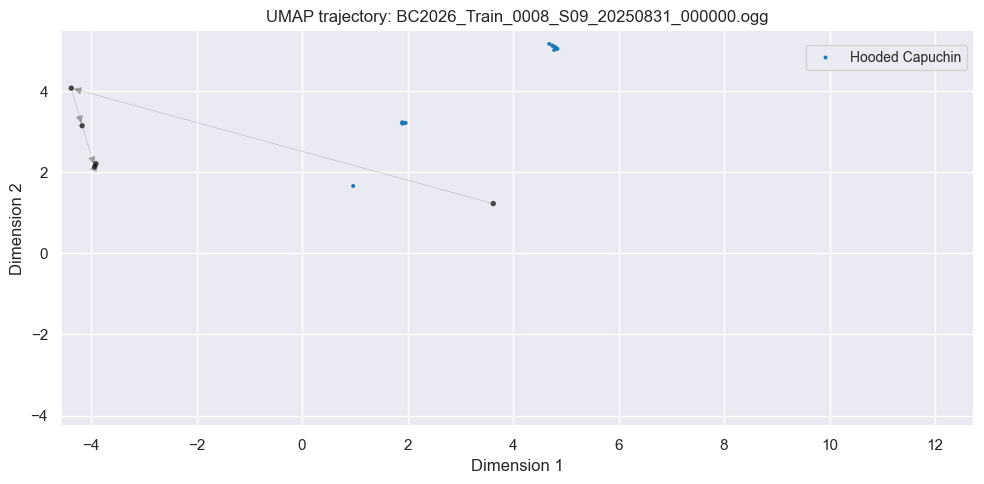

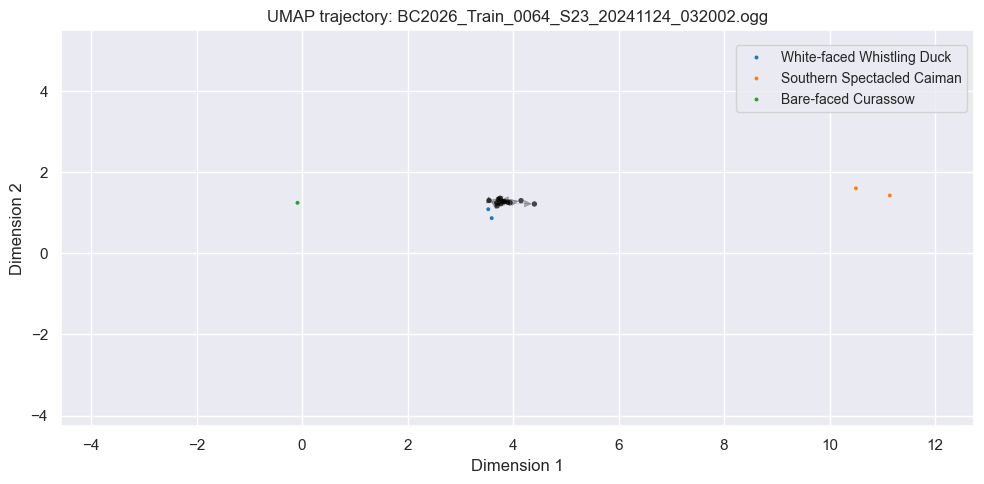

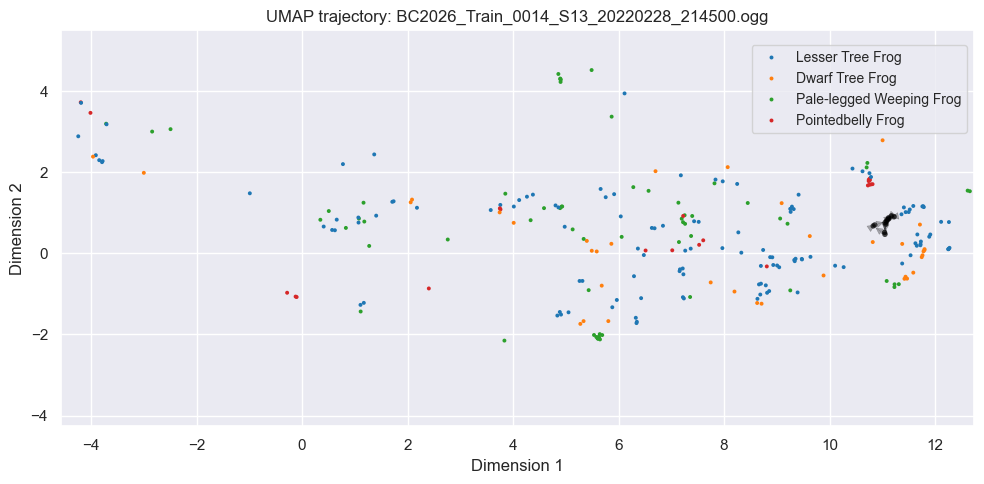

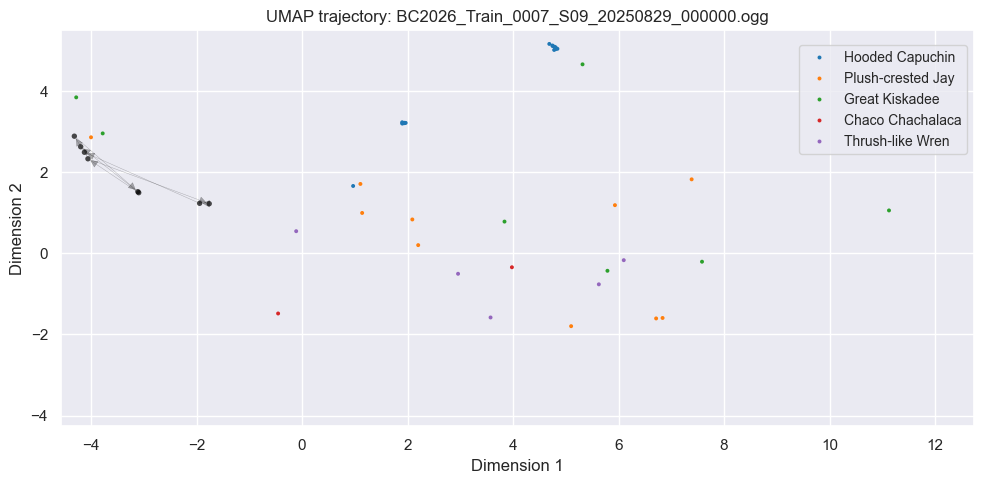

In [43]:
for f in filenames_subset:
    i = int(re.search(r"BC2026_Train_(\d{3,4})_", f).group(1))
    fig = plot_ss_trajectory(f)
    fig.savefig(f"plots/umap/{run_name}_ss_trajectory_{i}.jpg", dpi=150, bbox_inches="tight")

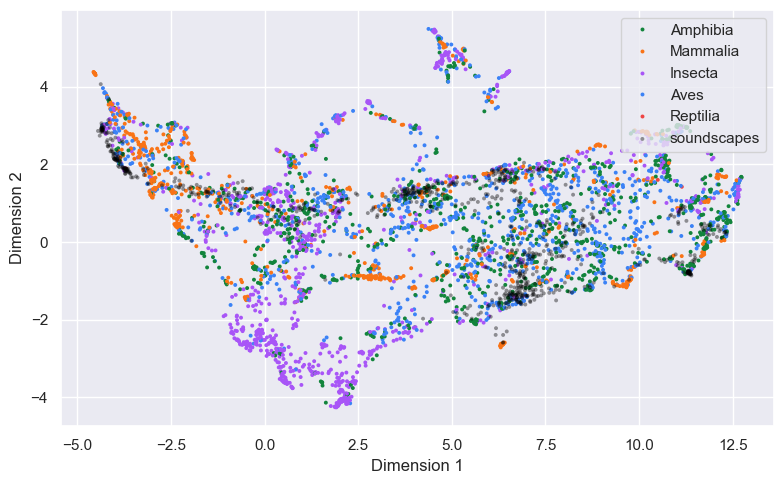

In [44]:
fig = plt.figure(figsize=(8, 5))
ax=sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=y_class_name_sample,
    palette=class_colors,
    s=8,
    edgecolor="none",
)

ax=sns.scatterplot(
    x=embeddings_ss[:, 0],
    y=embeddings_ss[:, 1],
    c="black",
    alpha=0.4,
    s=8,
    edgecolor="none",
    label="soundscapes"
)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")

plt.legend(loc="upper right")
plt.tight_layout()
fig.savefig(f"plots/umap/{run_name}_all.jpg", dpi=150, bbox_inches="tight")

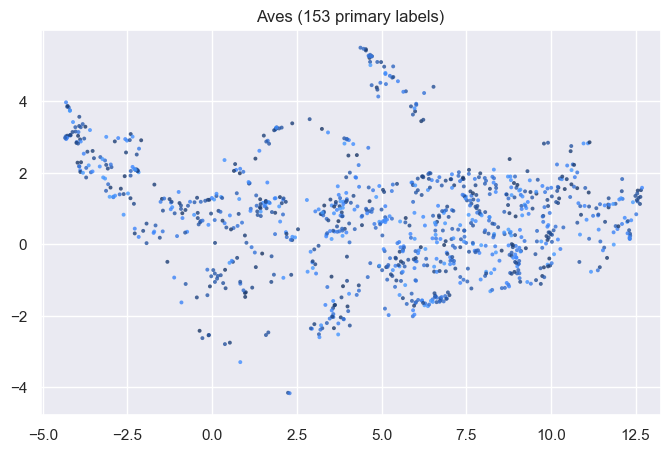

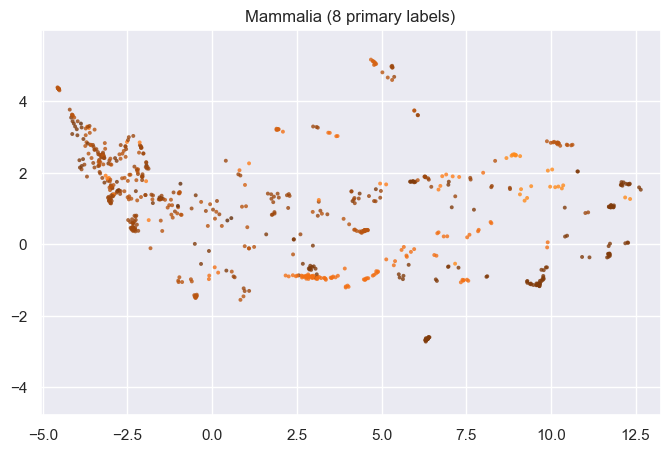

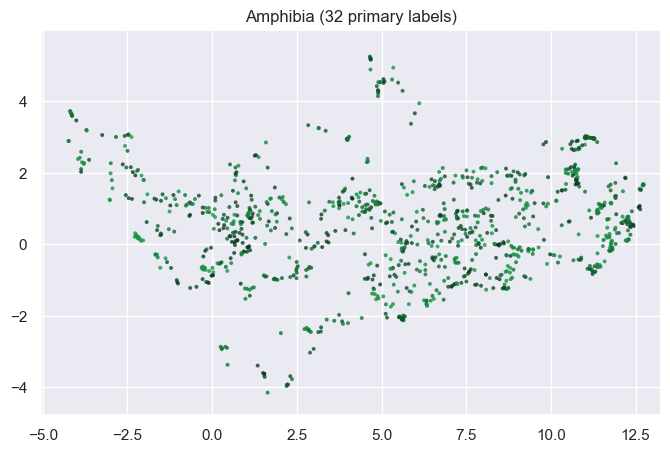

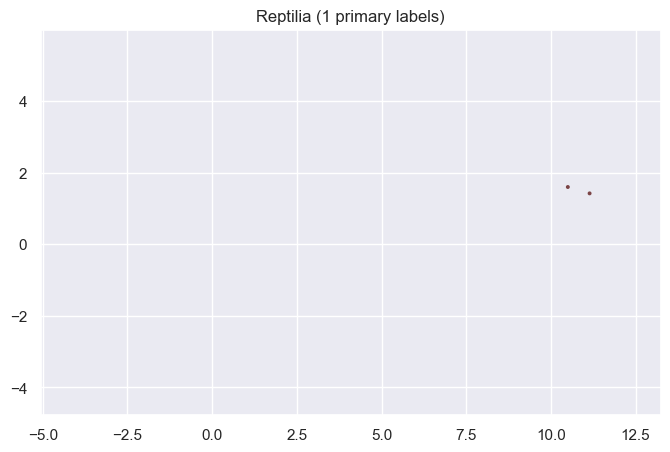

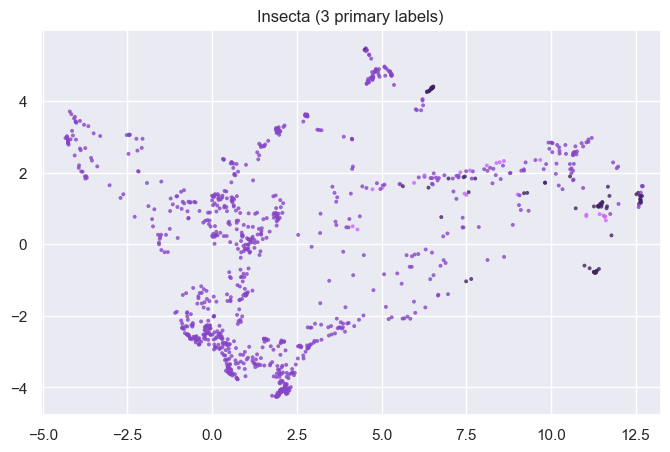

In [45]:
for class_name in class_colors.keys():
    fig = plot_umap_by_class(embeddings=embeddings, target_class=class_name)
    fig.savefig(f"plots/umap/{run_name}_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

## MIL

In [46]:
run_name = "run_mil"
dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=False)
dataset_ss = load_memmap_dataset(run_name, reduced=True, soundscape=True)
model, embeddings, y_class_name_sample, y_primary_label_sample = fit_umap(dataset)

filenames = np.array(dataset_ss.filenames)
unique_filenames = np.unique(filenames)

embeddings_ss = model.transform(dataset_ss.X)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


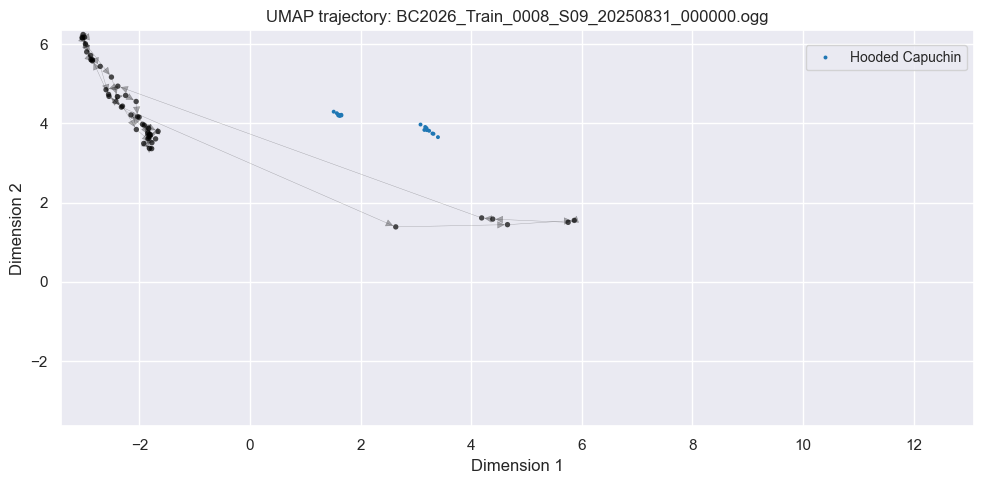

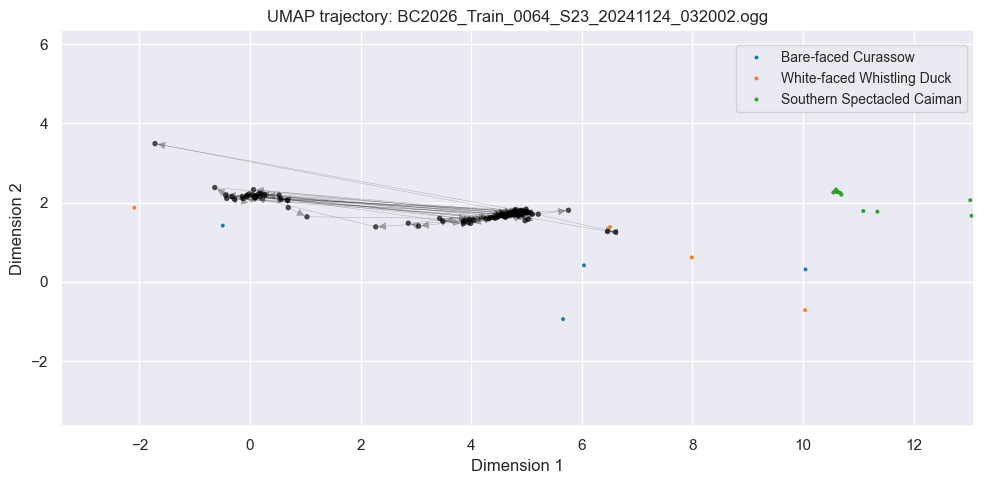

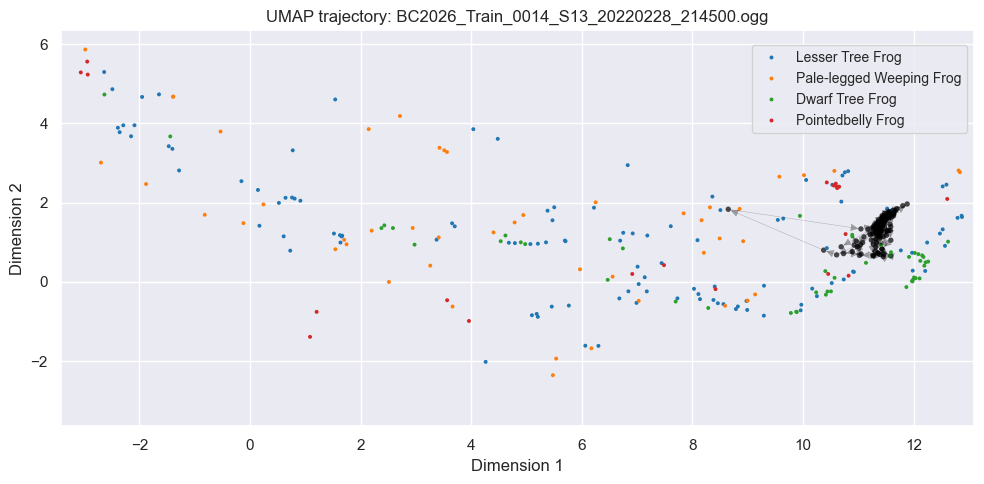

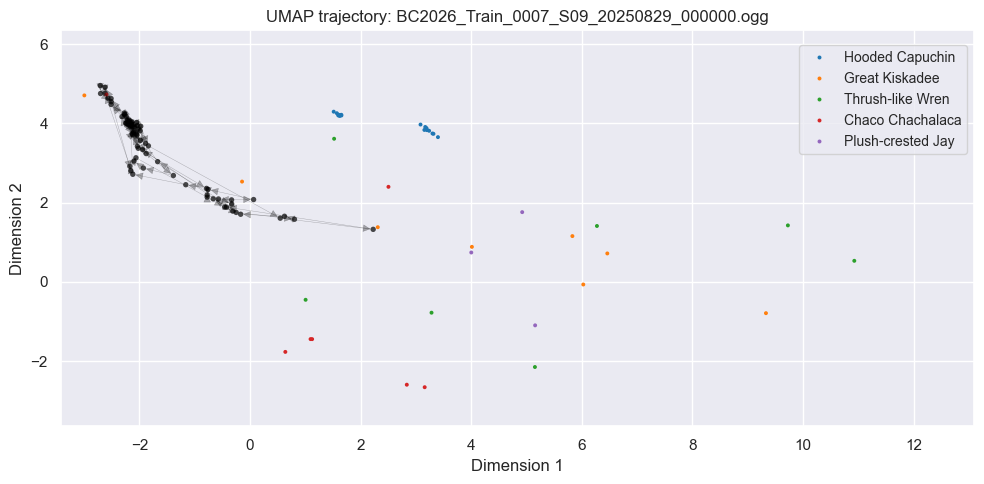

In [47]:
for f in filenames_subset:
    i = int(re.search(r"BC2026_Train_(\d{3,4})_", f).group(1))
    fig = plot_ss_trajectory(f)
    fig.savefig(f"plots/umap/{run_name}_ss_trajectory_{i}.jpg", dpi=150, bbox_inches="tight")

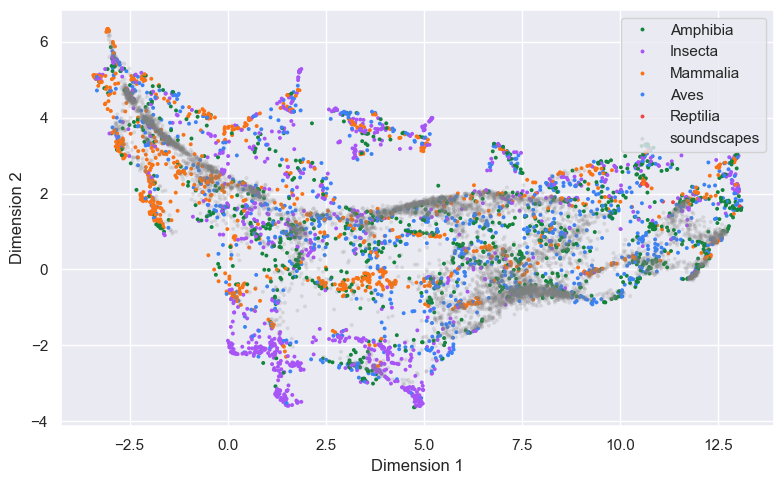

In [48]:
fig = plt.figure(figsize=(8, 5))
ax=sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=y_class_name_sample,
    palette=class_colors,
    s=8,
    edgecolor="none",
)


ax=sns.scatterplot(
    x=embeddings_ss[:, 0],
    y=embeddings_ss[:, 1],
    c="gray",
    alpha=0.2,
    s=8,
    edgecolor="none",
    label="soundscapes"
)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")

plt.legend(loc="upper right")
plt.tight_layout()
fig.savefig(f"plots/umap/{run_name}_all.jpg", dpi=150, bbox_inches="tight")

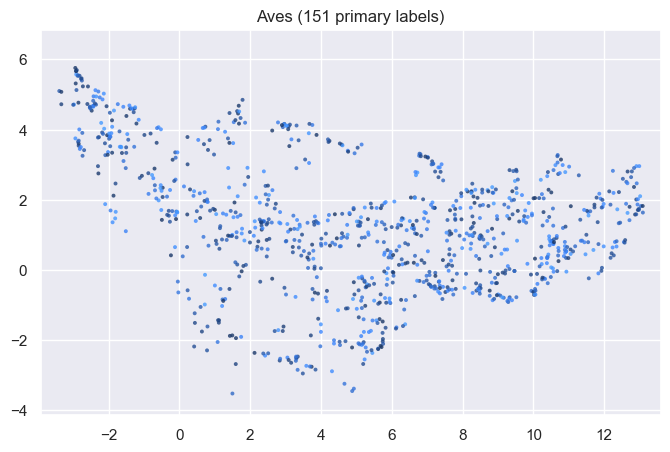

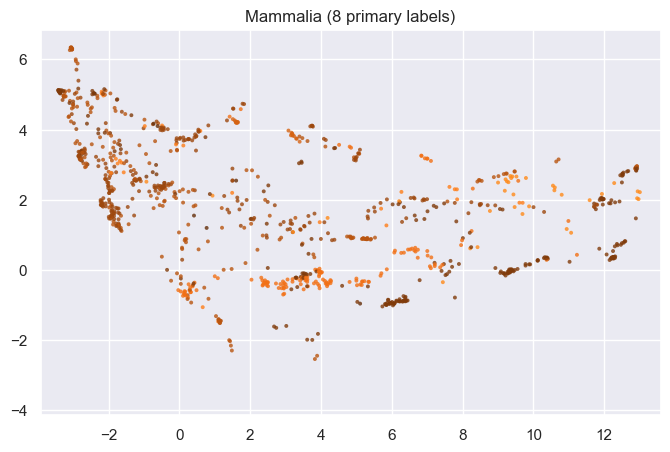

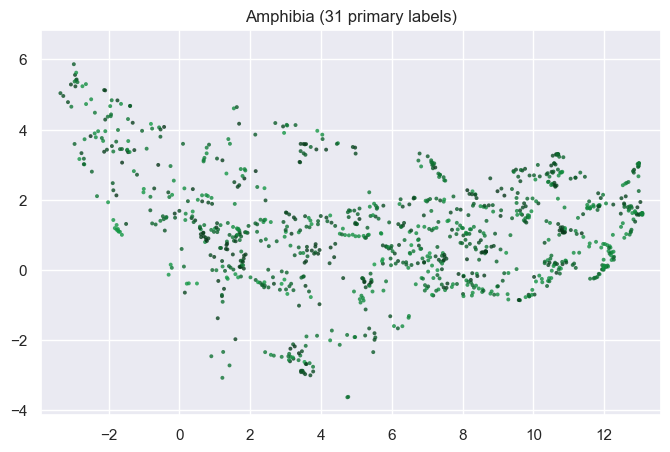

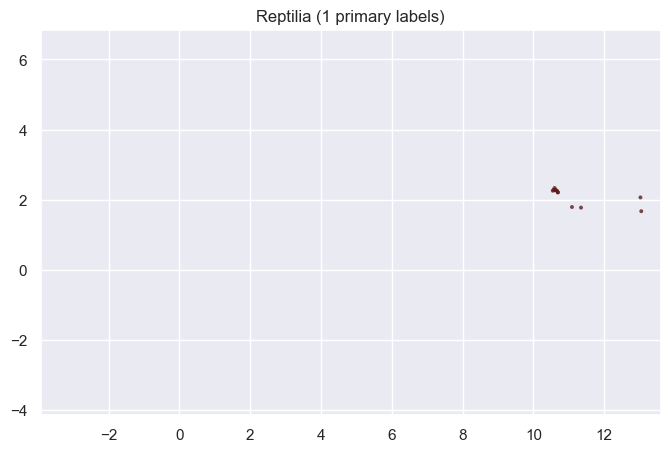

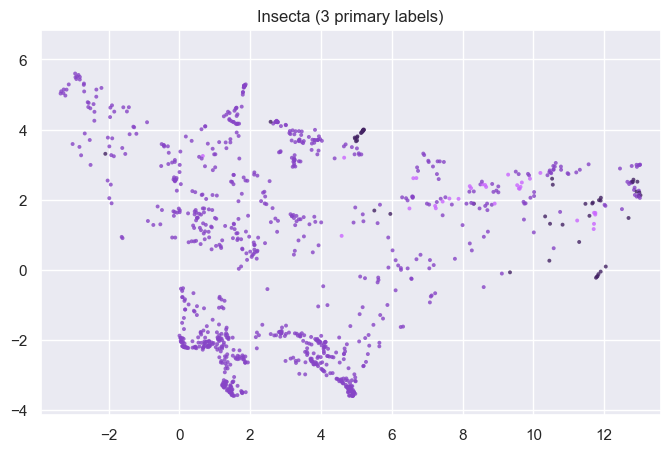

In [49]:
for class_name in class_colors.keys():
    fig = plot_umap_by_class(embeddings=embeddings, target_class=class_name)
    fig.savefig(f"plots/umap/{run_name}_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")